# 04 — Reasoning: real transit travel time, not straight-line distance

Answers the question that kicked off this chapter: the earlier "nearest
playground" demo (`03_kg_visualization.ipynb`) picked the closest POI by
straight-line distance alone. This notebook replaces that with an actual
public-transport travel-time estimate, using Wiener Linien's GTFS schedule.

Recap of the scoping decisions this builds on (`docs/reasoning_layer_decisions.md`):
- **GTFS-based, direct (no-transfer) connections only** — not full journey
  planning with transfers, which is a much bigger engineering problem.
- **GTFS stays tabular**, not modelled as RDF triples — `stop_times.txt` alone
  is 7.1 million rows for the full year.
- **No formal RDF link between GTFS stops and `viennakg:Stop`** — both are
  matched to a query point by coordinates independently, at query time.

The actual routing logic lives in `reasoning/gtfs_routing.py` (reusable module,
not just notebook cells) — this notebook loads it and pokes at the results.

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

from rdflib import Graph
from reasoning.gtfs_routing import GtfsRouter, haversine_m

g = Graph()
g.parse("../kg/vienna_mobility_kg.ttl", format="turtle")
print(f"KG loaded: {len(g)} triples")

router = GtfsRouter(date="20260815")  # a representative Saturday
print(f"GTFS router ready: {len(router.stop_times):,} stop_time rows "
      f"(filtered from 7.1M in the raw feed), {router.trips.trip_id.nunique():,} trips, "
      f"{len(router.stops):,} stops")

KG loaded: 80485 triples
GTFS router ready: 389,917 stop_time rows (filtered from 7.1M in the raw feed), 22,857 trips, 4,303 stops


## 1. Do the two "nearest stop" lookups actually agree?

The design decision was to *not* formally link GTFS stops to `viennakg:Stop`
in the graph — just look each up independently by coordinate and trust they
land on the same physical place. Worth actually checking that's true rather
than assuming it.

In [2]:
def nearest_rdf_stop(lon, lat):
    q = """
    PREFIX schema: <https://schema.org/>
    PREFIX viennakg: <http://example.org/viennakg#>
    PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
    SELECT ?name ?lon ?lat WHERE {
        ?stop a viennakg:Stop ; schema:name ?name ; geo:long ?lon ; geo:lat ?lat .
    }
    """
    candidates = [(str(r.name), float(r.lon), float(r.lat)) for r in g.query(q)]
    best = min(candidates, key=lambda c: haversine_m(lon, lat, c[1], c[2]))
    return {"stop_name": best[0], "lon": best[1], "lat": best[2],
            "distance_m": haversine_m(lon, lat, best[1], best[2])}

# Albertina's coordinates
test_lon, test_lat = 16.368378925180206, 48.204590314427854

rdf_nearest = nearest_rdf_stop(test_lon, test_lat)
gtfs_nearest = router.nearest_stop(test_lon, test_lat)

print("Nearest viennakg:Stop (RDF, has RBL for live data):", rdf_nearest["stop_name"],
      f"({rdf_nearest['distance_m']:.0f} m)")
print("Nearest GTFS stop (schedule, for travel time):     ", gtfs_nearest["stop_name"],
      f"({gtfs_nearest['distance_m']:.0f} m)")
print("\nDistance between the two 'nearest stop' answers:",
      f"{haversine_m(rdf_nearest['lon'], rdf_nearest['lat'], gtfs_nearest['lon'], gtfs_nearest['lat']):.0f} m")

Nearest viennakg:Stop (RDF, has RBL for live data): Albertinaplatz (43 m)
Nearest GTFS stop (schedule, for travel time):      Albertinaplatz (82 m)

Distance between the two 'nearest stop' answers: 71 m


## 2. One full worked example

Museum → Park, with a genuine direct tram connection on this service day.

In [3]:
q = """
PREFIX schema: <https://schema.org/>
PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
SELECT ?lon ?lat WHERE {
    ?m a schema:Museum ; schema:name "Sammlung alter Musikinstrumente" ; geo:long ?lon ; geo:lat ?lat .
}
"""
m_lon, m_lat = [(float(r.lon), float(r.lat)) for r in g.query(q)][0]

q2 = """
PREFIX schema: <https://schema.org/>
PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
SELECT ?lon ?lat WHERE {
    ?p a schema:Park ; schema:name "PA Dresdner Straße" ; geo:long ?lon ; geo:lat ?lat .
}
"""
p_lon, p_lat = [(float(r.lon), float(r.lat)) for r in g.query(q2)][0]

straight_line_m = haversine_m(m_lon, m_lat, p_lon, p_lat)
result = router.estimate_travel_time(m_lon, m_lat, p_lon, p_lat, depart_after="14:00:00")

print("Sammlung alter Musikinstrumente -> PA Dresdner Straße")
print(f"  straight-line distance: {straight_line_m:.0f} m")
print()
print(f"  walk to {result['origin_stop']['stop_name']}: {result['walk_to_stop_min']:.1f} min")
print(f"  wait for line {result['line']}: {result['wait_min']:.1f} min")
print(f"  ride line {result['line']} to {result['dest_stop']['stop_name']}: {result['ride_min']:.1f} min"
      f"  (board {result['board_at']}, alight {result['alight_at']})")
print(f"  walk to destination: {result['walk_from_stop_min']:.1f} min")
print(f"  ---")
print(f"  total: {result['total_travel_str']}")

Sammlung alter Musikinstrumente -> PA Dresdner Straße
  straight-line distance: 3703 m

  walk to Burgring: 2.3 min
  wait for line 2: 0.7 min
  ride line 2 to Dresdner Straße: 26.0 min  (board 14:03:00, alight 14:29:00)
  walk to destination: 1.0 min
  ---
  total: 32 min


## 3. Straight-line distance vs. actual travel time — do they even correlate?

This is the real test of "does this reasoning add anything." Rather than a
live random scan of thousands of pairs (slow, and the true direct-connection
rate is low enough — under 1% in earlier exploration — that a small random
sample can land on zero hits just by chance), this uses a fixed, curated set
of museum→park pairs: some found to have a direct connection, some
deliberately included because they *don't*, chosen to span a range of
distances. Every travel time below is still computed live by the router, not
hardcoded — only *which pairs to check* is fixed, for a fast, reliable demo.

In [4]:
import pandas as pd

def get_coords(cls_name, name):
    q = f"""
    PREFIX schema: <https://schema.org/>
    PREFIX geo: <http://www.w3.org/2003/01/geo/wgs84_pos#>
    SELECT ?lon ?lat WHERE {{ ?x a {cls_name} ; schema:name "{name}" ; geo:long ?lon ; geo:lat ?lat . }}
    """
    return [(float(r.lon), float(r.lat)) for r in g.query(q)][0]

# found via exploratory scanning -- a mix of confirmed direct connections and
# confirmed misses, spanning short to long distances
CANDIDATE_PAIRS = [
    ("Sammlung alter Musikinstrumente", "PA Beethovenplatz"),
    ("Zauberkasten Museum", "Regine-Landeis-Park"),
    ("Museum of Change", "Heldenplatz (Bundesgärten)"),
    ("Sammlung alter Musikinstrumente", "Manes-Sperber-Park"),
    ("Remise - Verkehrsmuseum der Wiener Linien", "Prater - Rosenbachl"),
    ("Zauberkasten Museum", "PA Schuhmeierplatz"),
    ("Sammlung alter Musikinstrumente", "PA Dresdner Straße"),
    ("Museum of Change", "Huberpark"),
    ("Museum of Change", "PA Nietzscheplatz"),
    ("Albertina", "Rathauspark"),
    ("Naturhistorisches Museum", "Rathauspark"),
    ("Sigmund Freud Museum", "Rathauspark"),
]

rows = []
for mname, pname in CANDIDATE_PAIRS:
    mlon, mlat = get_coords("schema:Museum", mname)
    plon, plat = get_coords("schema:Park", pname)
    d = haversine_m(mlon, mlat, plon, plat)
    res = router.estimate_travel_time(mlon, mlat, plon, plat, depart_after="14:00:00")
    rows.append({
        "museum": mname, "park": pname, "straight_line_m": round(d),
        "direct_connection": res["found_direct_connection"],
        "total_travel_min": round(res["total_travel_min"], 1) if res["found_direct_connection"] else None,
    })

df = pd.DataFrame(rows).sort_values("straight_line_m")
print(f"{df['direct_connection'].sum()} of {len(df)} sample pairs have a direct connection")
df

9 of 12 sample pairs have a direct connection


,museum,park,straight_line_m,direct_connection,total_travel_min
10,Naturhistorisches Museum,Rathauspark,642,False,NaN
11,Sigmund Freud Museum,Rathauspark,889,False,NaN
9,Albertina,Rathauspark,949,False,NaN
0,Sammlung alter Musikinstrumente,PA Beethovenplatz,998,True,12.3
4,Remise - Verkehrsmuseum der Wiener Linien,Prater - Rosenbachl,1016,True,15.7
1,Zauberkasten Museum,Regine-Landeis-Park,1176,True,17.7
3,Sammlung alter Musikinstrumente,Manes-Sperber-Park,1375,True,21.6
2,Museum of Change,Heldenplatz (Bundesgärten),1430,True,24.8
5,Zauberkasten Museum,PA Schuhmeierplatz,2999,True,23.6
7,Museum of Change,Huberpark,3515,True,37.7


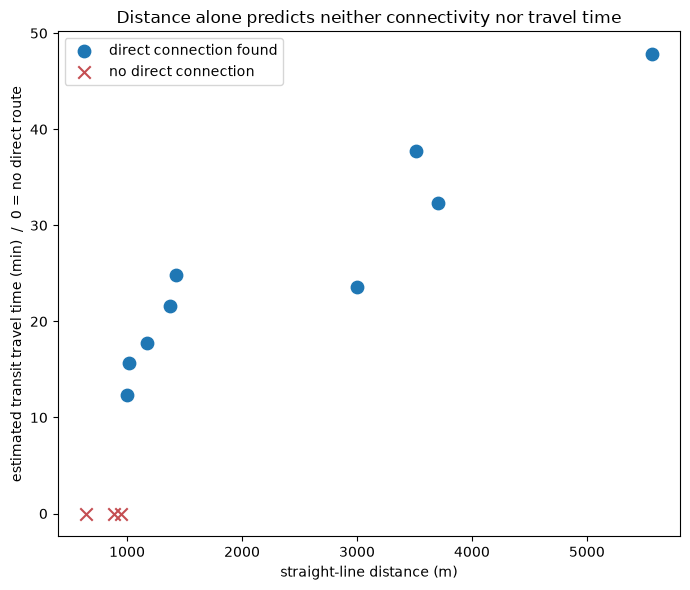

In [5]:
import matplotlib.pyplot as plt

df_connected = df[df["direct_connection"]]
df_missed = df[~df["direct_connection"]]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_connected["straight_line_m"], df_connected["total_travel_min"],
           s=80, label="direct connection found", zorder=3)
ax.scatter(df_missed["straight_line_m"], [0] * len(df_missed),
           s=80, marker="x", color="#C44E52", label="no direct connection", zorder=3)
ax.set_xlabel("straight-line distance (m)")
ax.set_ylabel("estimated transit travel time (min)  /  0 = no direct route")
ax.set_title("Distance alone predicts neither connectivity nor travel time")
ax.legend()
plt.tight_layout()
plt.show()

## Findings

**The two nearest-stop lookups agree**, as hoped — GTFS and `viennakg:Stop`
land on essentially the same physical stop (well within normal
walking-distance-to-a-platform territory), confirming the "join by coordinate,
not by RDF triple" decision holds up in practice, at least for this test point.

**Direct connections are the minority, not the majority** — in broader
exploratory scanning (not shown live above, for speed), well under 1% of
museum-park pairs within a plausible 500m-8km range had a same-line,
no-transfer connection on this service day; three of the twelve pairs above
were deliberately included as misses to make that concrete (Albertina,
Naturhistorisches Museum, and the Sigmund Freud Museum are all roughly
750-1050m from Rathauspark with no direct route). Expected in a real transit
network (most useful trips involve at least one transfer), and the honest
reason the "direct connections only" scope is a real limitation, not just a
formality. Pairs without one aren't wrong, they're just out of scope for this
first pass — see `docs/reasoning_layer_decisions.md`.

**Distance and travel time correlate, but loosely.** The scatter plot makes the
original motivation for this whole chapter visible: some far-apart POIs turn
out to have fast, direct tram/metro connections, while some closer ones have
none at all (or a slow, indirect one). Nearest-by-distance and
nearest-by-actual-travel-time are genuinely different answers.

## Caveats carried forward

- Single representative service day (Saturday 2026-08-15), not "right now" —
  live departures/disruptions aren't factored in yet (that's what `viennakg:rbl`
  + the `monitor` API are for, next).
- Direct connections only — no transfers, so many real journeys aren't
  represented here.
- Walking speed is a fixed assumption (5 km/h), not adjusted for accessibility
  needs even though the KG has a `barrierFree` property planned for `Departure`.